In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
import time

In [2]:
# define state:

class CrashState(TypedDict):

    input: str
    state1: str 
    state2: str
    state3: str 

In [3]:
def state1(state: CrashState):
    print('Step 1 Executed')
    return {'state1': 'Done', 'input': state['input']}

def state2(state: CrashState):
    print("Step 2 hanging...... now manually interrupt from the notebook toolbar")
    time.sleep(30)
    return {'state2': 'Done'}

def state3(state: CrashState):
    print('Step 3 Executed')
    return {'Done': True}



In [5]:
# Define StateGraph:

graph = StateGraph(CrashState)

# add node
graph.add_node('state1', state1)
graph.add_node('state2', state2)
graph.add_node('state3', state3)

# add edge

graph.add_edge(START, 'state1')

graph.add_edge('state1', 'state2')

graph.add_edge('state2', 'state3')

graph.add_edge('state3', END)


# define checkpointer
checkpointer = InMemorySaver()


# Comiple

workflow = graph.compile(checkpointer = checkpointer )

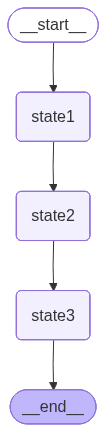

In [6]:
# show the workflow

from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)


In [ ]:
# execute the workflow.

